In [9]:
import json
import os
import time

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from ase import Atoms
import yaml

from fairchem.core.common.tutorial_utils import fairchem_main

import torch
from fairchem.core.datasets import LmdbDataset
from sklearn.metrics import r2_score, mean_absolute_error

In [10]:
def collect_result(dft_path, prd_path, target, application=False):
    '''
    dft_path: input test set (lmdb format).
    prd_path: test prediction output, file name is ocp_predictions.npz 
    target  : target property name in lmdb
    application: Ture if the trained model is used for application.
                 False if it is used to collect output of test result.
    '''
    dft_raw = LmdbDataset({"src": dft_path})
    prd_raw = np.load(prd_path)
    # prd_raw.files

    if not application:
        dft = np.array([data[target] for data in dft_raw])
    
    # get ml result from output
    ids = [int(i.split('_')[1]) for i in prd_raw['ids']]
    inverse_ids = np.argsort(ids)
    prd = np.array([i[0] for i in prd_raw['energy']])
    prd = prd[inverse_ids]
    
    # create pandas dataframe
    dataset = LmdbDataset({"src": dft_path})
    data_list = []
    for ind, data in enumerate(dataset):
        # Customize keys depending on what's in each data sample
        row = {
            "id":     data.id,
            'UUID':   data.UUID,
            target + "_ML" : prd[ind],
        }
        if not application:
            row[target + "_DFT"] = dft[ind]
            # row[target + "_ML" ] = data[target]
            
        data_list.append(row)
    
    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    
    return df

## This notebook contains:
1. Train a model of Tc from scratch.

This is used as the base line and compared with transfer learning results obtained in the other notebook,

Please copy `set_example_trainTL` obtained by example 1 to this folder.

## Train model with GPU

In [11]:
run_dir = f"result_Tc"   

job_name='Tc_scratch'   

config    = f"./config_{job_name}.yml"
log_file  = f"log_train_{job_name}.txt"
warn_file = f"warn_train_{job_name}.txt"


In [12]:
# print GPUs
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")

Device 0: NVIDIA RTX 6000 Ada Generation
Device 1: NVIDIA RTX 6000 Ada Generation
Device 2: Quadro GV100
Device 3: Quadro GV100


In [13]:
t0 = time.time()
! CUDA_VISIBLE_DEVICES={3}  \
python {fairchem_main()} --mode train --config-yml {config}           \
                         --run-dir {run_dir}  --identifier {job_name} \
                         --print-every 50 \
                         > {log_file} 2>  {warn_file}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

Elapsed time = 1551.6 seconds


In [14]:
# Obtain output dir for later convenience.
# This dir contains trained model (checkpoint).  
cpline = !grep "checkpoint_dir:" {log_file}
cpdir  = cpline[0].split(':')[-1].strip()
print(cpdir)

result_Tc/checkpoints/2025-10-11-18-16-48-Tc_scratch


In [15]:
# copy config file to the ouput dir for future need.
! cp {config} {cpdir}'/config.yml'

## Collect results of test set. 


In [16]:
# path to test lmdb set which should be same as the config file.
dft_path = "set_example_trainTL/test.lmdb" 
# path to ML prediction; set automatically here
prd_path = cpdir.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to test set used for training: ', dft_path)
print('Path to test prediction by ML: ',      prd_path)

# The ML prediction and True values (DFT values) are collected to df and saved.
# target is the target property, which is the name in lmdb database and should be same as config file.
# application is Flase since we are not using model to predict new compounds.
df = collect_result(dft_path, prd_path, target='Tc', application=False)
df.to_csv('./performance_test_scratch.csv')


Path to test set used for training:  set_example_trainTL/test.lmdb
Path to test prediction by ML:  result_Tc/results/2025-10-11-18-16-48-Tc_scratch/ocp_predictions.npz


In [17]:
# the top 4 rows.
df.head(4)

,id,UUID,Tc_ML,Tc_DFT
0,104693,2abc4d30-11e6-45e4-9937-24be12f965a5,9.835938,0.0
1,19519,f3303db4-c9bb-4970-8b35-0e410932dd83,342.500000,540.6
2,16402,d7be146b-5da3-4875-9da6-319abce48ec6,28.953125,0.5
3,13358,261382e9-91ad-48cf-99e0-efc0b5d825b1,675.500000,749.8


#### Make a scatter plot with R2 and MAE
Here a scatter plot is used to understand the performance of the trained model. 
Please note, this is based on test set, not train set.

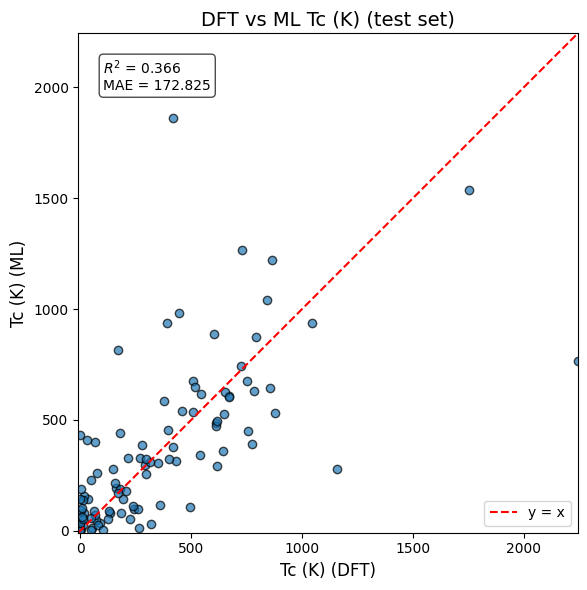

In [19]:
df = pd.read_csv('performance_test_scratch.csv', index_col=0)
target = 'Tc'

# Compute metrics
r2 = r2_score(df[target+'_DFT'], df[target+'_ML'])
mae = mean_absolute_error(df[target+'_DFT'], df[target+'_ML'])

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(df[target+'_DFT'], df[target+'_ML'], alpha=0.7, edgecolor='k')

# 1:1 line
lims = [
    min(df[target+'_DFT'].min(), df[target+'_ML'].min()),
    max(df[target+'_DFT'].max(), df[target+'_ML'].max())
]
plt.plot(lims, lims, 'r--', label='y = x')

# Labels, title
plt.xlabel("Tc (K) (DFT)", fontsize=12)
plt.ylabel("Tc (K) (ML)", fontsize=12)
plt.title("DFT vs ML Tc (K) (test set)", fontsize=14)

# Same scale for x and y
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# Add metrics as text inside plot
plt.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.legend()
plt.tight_layout()
plt.savefig('fig_performance_scratch.png')
plt.show()
